In [3]:
%run 10_MNESIS_polychronous-chains.ipynb

datetag = '2026-04-21'
SNNtorch version 0.9.4
Spikes in one target 1024.0,  in a SM window 42.0
for a value opt.lif_beta=0.7, the time constant is 2.8 steps
Spikes in one target 1024.0,  in a SM window 42.0
for a value opt.lif_beta=0.7, the time constant is 2.8 steps


## learning traveling waves patterns patterns

In [4]:
opt = Params()
hd = HD_SNN(opt)
hd.target.shape, opt, int(opt.N_neuron**.5)

(torch.Size([16, 1024, 1000]),
 Params(datetag='2026-04-21', N_neuron=1024, num_delay=41, N_SM=16, N_time=1000, N_pretime=50, p_A=0.001, seed=2018, lif_beta=0.7, learn_beta=False, learn_threshold=False, do_deconv=False, num_epochs=16, num_warmup_epochs=16, base_lr=0.001, final_lr=0.0001, delta1=0.01, delta2=5e-05, weight_decay=1e-09, init_gain=1.5, dropout=0.37, alpha_surrogate=15.0, surrogate_name='FastSigmoid', loss_name='SpikeF1scoreLoss', reset_mechanism='subtract', optimizer='sgd', verbose=False, fig_width=15, fig_height=9, phi=1.61803, N_time_show=400, N_neuron_show=256, N_scan=17),
 32)

In [37]:
import MotionClouds as mc
import numpy as np
# define Fourier domain
mc.N_X, mc.N_Y, mc.N_frame = int(opt.N_neuron**.5), int(opt.N_neuron**.5), opt.N_time
fx, fy, ft = mc.get_grids(mc.N_X, mc.N_Y, mc.N_frame)
# define an envelope
envelope = mc.envelope_gabor(fx, fy, ft,
    V_X=1., V_Y=0., B_V=.1,
    sf_0=.15, B_sf=.1,
    theta=0., B_theta=np.pi/8
    )
movie = mc.random_cloud(envelope)
movie = mc.rectif(movie)
movie = (2*movie - 1)
movie.min(), movie.max()

(np.float64(-0.9397680760900274), np.float64(1.0))

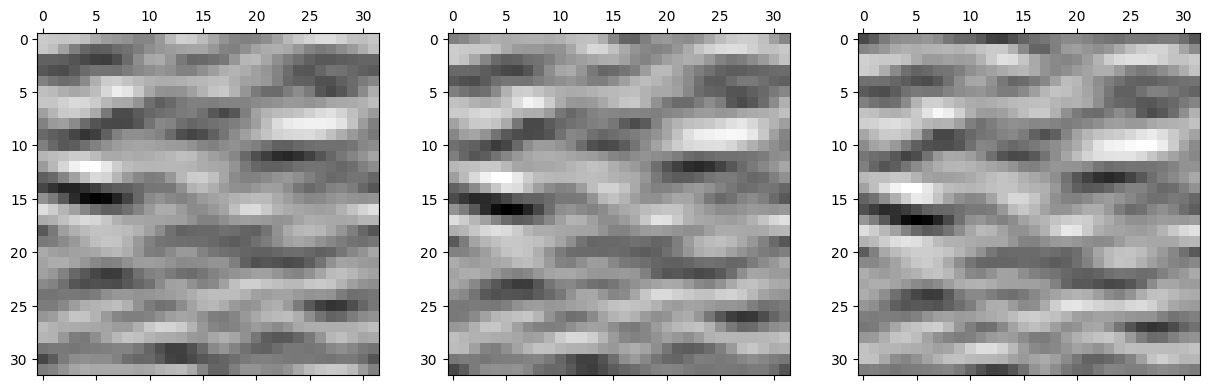

In [38]:
fig, axs = plt.subplots(1, 3, figsize=(opt.fig_width, opt.fig_width/phi))
for i_ax, ax in enumerate(axs):
    ax.matshow(movie[:, :, i_ax], cmap='gray')

In [ ]:
movie_gain = 4.
A_proba = torch.sigmoid(torch.logit(torch.tensor(opt.p_A)) + movie_gain * movie) 

A_proba.shape, torch.bernoulli(A_proba[0, 0, :20])

/var/folders/3s/q2x8bxzj43g4rdvb2wjt67640000gq/T/ipykernel_63898/1987267720.py:2: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  A_proba = torch.sigmoid(torch.logit(torch.tensor(opt.p_A)) + movie_gain * movie)


(torch.Size([32, 32, 1000]),
 tensor([1., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=torch.float64))

In [40]:
A = torch.bernoulli(A_proba)

In [41]:
A_proba.mean(), A.mean()

(tensor(0.225, dtype=torch.float64), tensor(0.225, dtype=torch.float64))

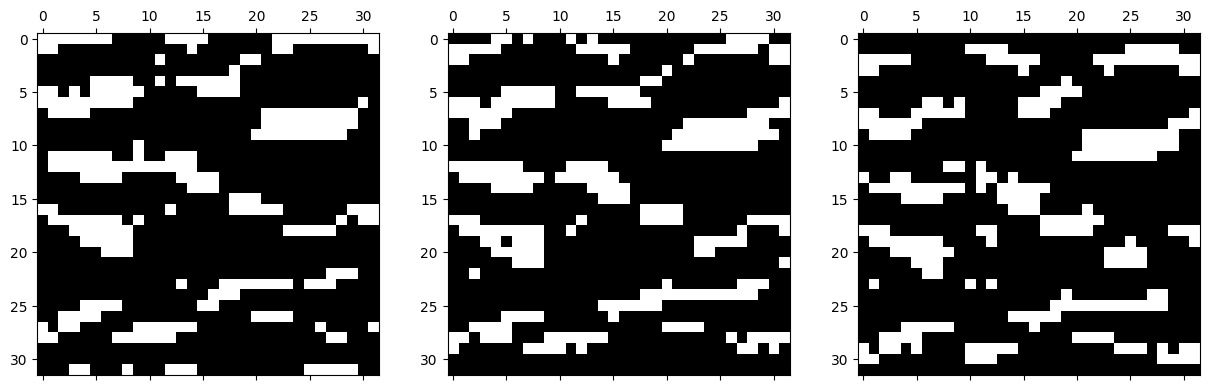

In [42]:
fig, axs = plt.subplots(1, 3, figsize=(opt.fig_width, opt.fig_width/phi))
for i_ax, ax in enumerate(axs):
    ax.matshow(A[:, :, i_ax], cmap='gray')

In [44]:
if figpath is not None:
    import matplotlib.animation as animation

    # Create the figure and axis
    fig, ax = plt.subplots(figsize=(opt.fig_width, opt.fig_width))

    im = ax.imshow(A[:, :, 0], cmap='gray', vmin=0, vmax=1)
    ax.axis('off')  # turn off axes

    def animate(frame):
        im.set_array(A[:, :, frame])
        ax.set_title(f"Frame {frame}")
        return [im]

    # ax.set_xlabel("X")
    # ax.set_ylabel("Y")

    anim = animation.FuncAnimation(
        fig,
        animate,
        frames=movie.shape[2],
        interval=40,     # ms per frame
        blit=False,
        repeat=True
    )
    # Save as gif or mp4
    # anim.save(figpath / 'retrieval_animation.gif', writer='pillow', fps=20)
    anim.save(figpath / 'TW.mp4', writer='ffmpeg', fps=25)
    plt.close()

## learning traveling waves patterns patterns

In [ ]:
opt = Params()
hd = HD_SNN(opt)
hd.net.to(hd.opt.device)

# Make the target periodic
hd.target[:, :, :] = TW


Model file not found: ../cached_data/2026-04-21_periodic.pth, intitializing the new model.


/var/folders/3s/q2x8bxzj43g4rdvb2wjt67640000gq/T/ipykernel_56258/3309586140.py:90: UserWarning: The operator 'aten::linalg_svd' is not currently supported on the MPS backend and will fall back to run on the CPU. This may have performance implications. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/mps/MPSFallback.mm:34.)
  X_pinv = torch.linalg.pinv(contexts)  # [N_neuron * num_delay, total_samples]


Train Epoch [000001/000016]	| Loss = 0.000e+00	| precision = 1.000	| recall = 1.000	| f1_score = 1.000	| 
Train Epoch [000002/000016]	| Loss = 0.000e+00	| precision = 1.000	| recall = 1.000	| f1_score = 1.000	| 
Train Epoch [000003/000016]	| Loss = 0.000e+00	| precision = 1.000	| recall = 1.000	| f1_score = 1.000	| 
Train Epoch [000004/000016]	| Loss = 0.000e+00	| precision = 1.000	| recall = 1.000	| f1_score = 1.000	| 
Train Epoch [000005/000016]	| Loss = 0.000e+00	| precision = 1.000	| recall = 1.000	| f1_score = 1.000	| 


In [ ]:

model_filename = data_cache / f"{hd.opt.datetag}_periodic.pth"
lock_filename = data_cache / model_filename.with_suffix('.lock')
# if False:
if RECOMPUTE:
    model_filename.unlink(missing_ok=True) # FORCING RECOMPUTE
    lock_filename.unlink(missing_ok=True) # FORCING RECOMPUTE
try:
    model_state_dict = torch.load(model_filename, map_location=torch.device(hd.opt.device))
    hd.net.load_state_dict(model_state_dict)
    hd.net.eval()
    lock_filename.unlink(missing_ok=True) # in case the lock file was not unlinked
    print(f"Model weights loaded from {model_filename}") # Add a log message
except FileNotFoundError:
    if not lock_filename.exists():
        print(f"Model file not found: {model_filename}, intitializing the new model.")
        lock_filename.touch(exist_ok=True)
        ##################
        hd.update_weight()
        hd.learn_model()
        ##################
        torch.save(hd.net.state_dict(), model_filename)
        lock_filename.unlink(missing_ok=True)
    else:
        print(f"Model file is locked: {lock_filename}, passing.")

In [ ]:
with torch.no_grad():
    target_full = torch.nn.functional.pad(hd.target, (opt.N_pretime, opt.N_pretime))
    input_spikes = hd.get_input_spikes(p_A=hd.opt.p_A, N_pretime=hd.opt.N_pretime, N_trigger_time=hd.opt.num_delay)
    _, _, spikes = hd.forward_pass(input_spikes)
    spikes_evoked = spikes[:, :, (hd.opt.N_pretime+hd.opt.num_delay):(-hd.opt.N_pretime)]
    target_evoked = hd.target[:, :, hd.opt.num_delay:]

    precision, recall, f1_score = get_scores(spikes_evoked, target_evoked)
    print(f'precision = {precision:.3f}\t recall = {recall:.3f}\t f1_score = {f1_score:.3f} ')

In [ ]:
fig,ax = plt.subplots(figsize=(13, 8))
splt.raster(spikes[i_SM, :opt.N_neuron_show, :opt.N_time_show].T, ax, s=25, c="blue", marker='+', alpha=.5)
splt.raster(target_full[i_SM, :opt.N_neuron_show, :opt.N_time_show].T, ax, s=25, facecolor='none', edgecolor='red',  marker='o', alpha=.5)
splt.raster(input_spikes[i_SM, :opt.N_neuron_show, :opt.N_time_show].T, ax, s=25, c="green", marker='x', alpha=.5)
ax.vlines([opt.N_pretime], 0, opt.N_neuron_show, 'r', ls='--')
ax.vlines([opt.N_pretime+opt.num_delay], 0, opt.N_neuron_show, 'b', ls='--')
ax.set_xlabel("Time step (ms)")
ax.set_ylabel("Neuron Address")
ax.set_ylim(-1., opt.N_neuron_show + 1.)
if figpath is not None: printfig(fig, 'target', fig_width=opt.fig_width, fig_height=opt.fig_height)
spikes.shape, spikes[i_SM, :, :].sum().item(), hd.target[i_SM, :, :].sum().item()

In [ ]:
# hd.net.lin.bias.cpu().detach().numpy()
fig,ax = plt.subplots(figsize=(13, 8))
ax.hist(hd.net.lin.weight.cpu().detach().numpy().ravel(), bins=100, density=True) # pyright: ignore[reportCallIssue, reportAttributeAccessIssue]
ax.set_yscale('log')